**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4033 - Visión computacional para imágenes y video**

Tecnológico de Monterrey

Prof Gilberto Ochoa Ruiz

**Semana 5**
Algoritmos de mejoramiento de imágenes en el dominio de Fourier

---

**Equipo 23**

|                 NOMBRE              | MATRÍCULA |
|-------------------------------------|-----------|
| Luis Fernando Caporal Montes de Oca | A01795898 |  
| David Alexis García Espinosa        | A01795178 |
| Jorge Santana Mendoza               | A01376306 |
| José Manuel Romo Peredo             | A0        |
| Luis Daniel Ortega Muñoz            | A01795197 |
             

# 5. Frequency Domain

## Table of Contents
1. [Libraries](#libraries)
2. [Fast Fourier Transform (FFT)](#fft)
3. [Low Pass Filter](#low)
4. [High Pass Filter](#high)
5. [Ejercicios](#ejer)
6. [Referencias](#ref)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt,exp
from PIL import Image

## Fast Fourier Transform (FFT) <a class="anchor" id="fft" ></a>

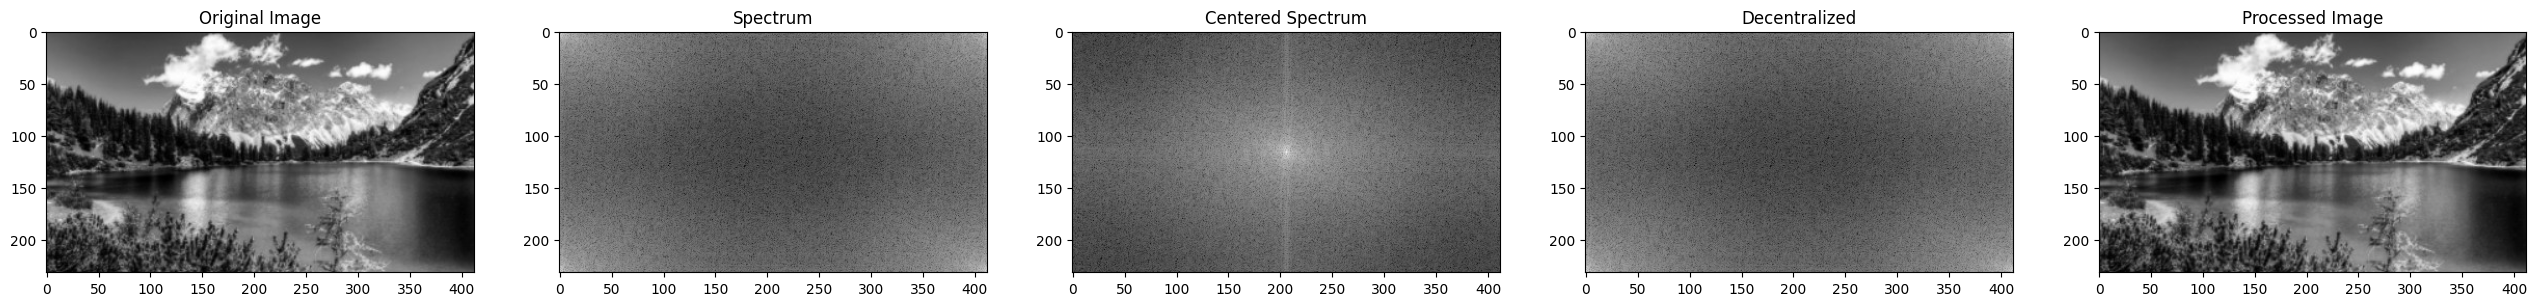

In [2]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("image.jpg", 0)
plt.subplot(151), plt.imshow(img, "gray"), plt.title("Original Image")

original = np.fft.fft2(img)
plt.subplot(152), plt.imshow(np.log(1+np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(153), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Centered Spectrum")

inv_center = np.fft.ifftshift(center)
plt.subplot(154), plt.imshow(np.log(1+np.abs(inv_center)), "gray"), plt.title("Decentralized")

processed_img = np.fft.ifft2(inv_center)
plt.subplot(155), plt.imshow(np.abs(processed_img), "gray"), plt.title("Processed Image")

plt.show()

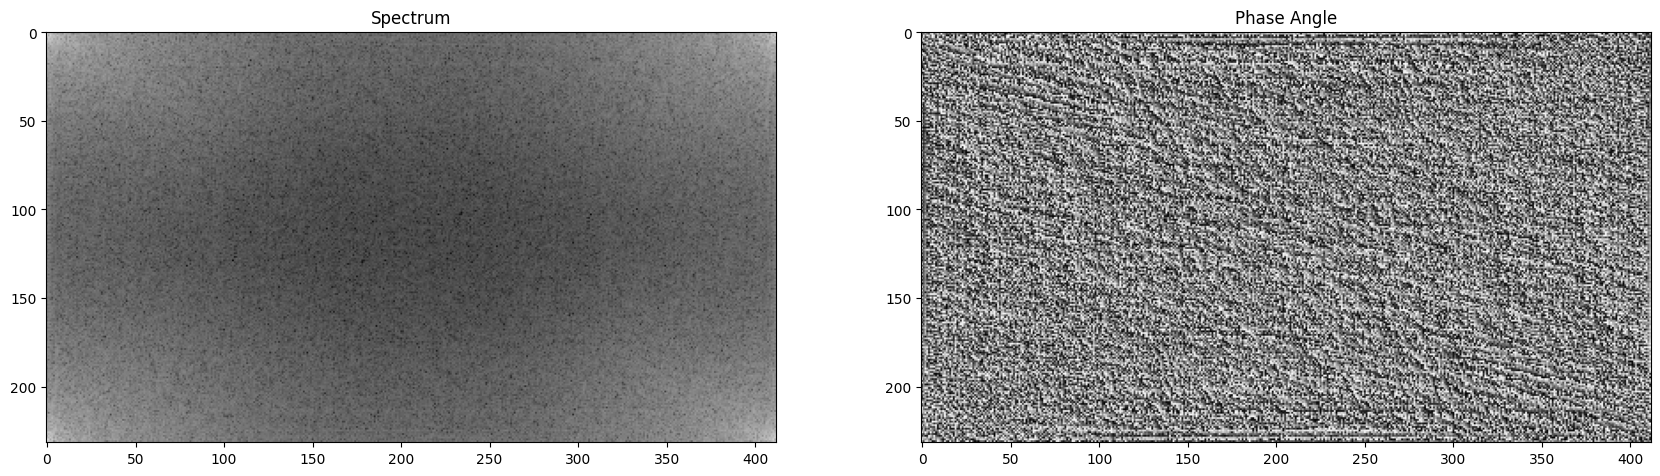

In [3]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("image.jpg", 0)

original = np.fft.fft2(img)
plt.subplot(131), plt.imshow(np.log(np.abs(original)), "gray"), plt.title("Spectrum")

plt.subplot(132), plt.imshow(np.angle(original), "gray"), plt.title("Phase Angle")
plt.show()

In [4]:
def distance(point1,point2):
    return sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)

def idealFilterLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 1
    return base

def idealFilterHP(D0,imgShape):
    base = np.ones(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 0
    return base

def butterworthLP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1/(1+(distance((y,x),center)/D0)**(2*n))
    return base

def butterworthHP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1-1/(1+(distance((y,x),center)/D0)**(2*n))
    return base

def gaussianLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

def gaussianHP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1 - exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

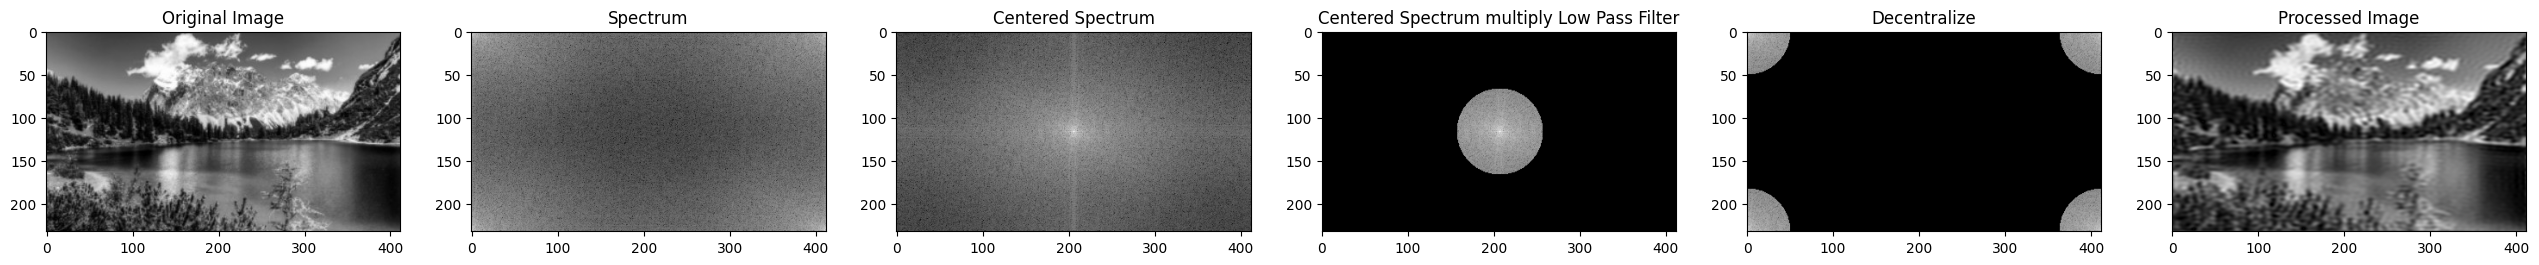

In [5]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("image.jpg", 0)
plt.subplot(161), plt.imshow(img, "gray"), plt.title("Original Image")

original = np.fft.fft2(img)
plt.subplot(162), plt.imshow(np.log(1+np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(163), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Centered Spectrum")

LowPassCenter = center * idealFilterLP(50,img.shape)
plt.subplot(164), plt.imshow(np.log(1+np.abs(LowPassCenter)), "gray"), plt.title("Centered Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(165), plt.imshow(np.log(1+np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(166), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

## Low Pass Filter <a class="anchor" id="low" ></a>

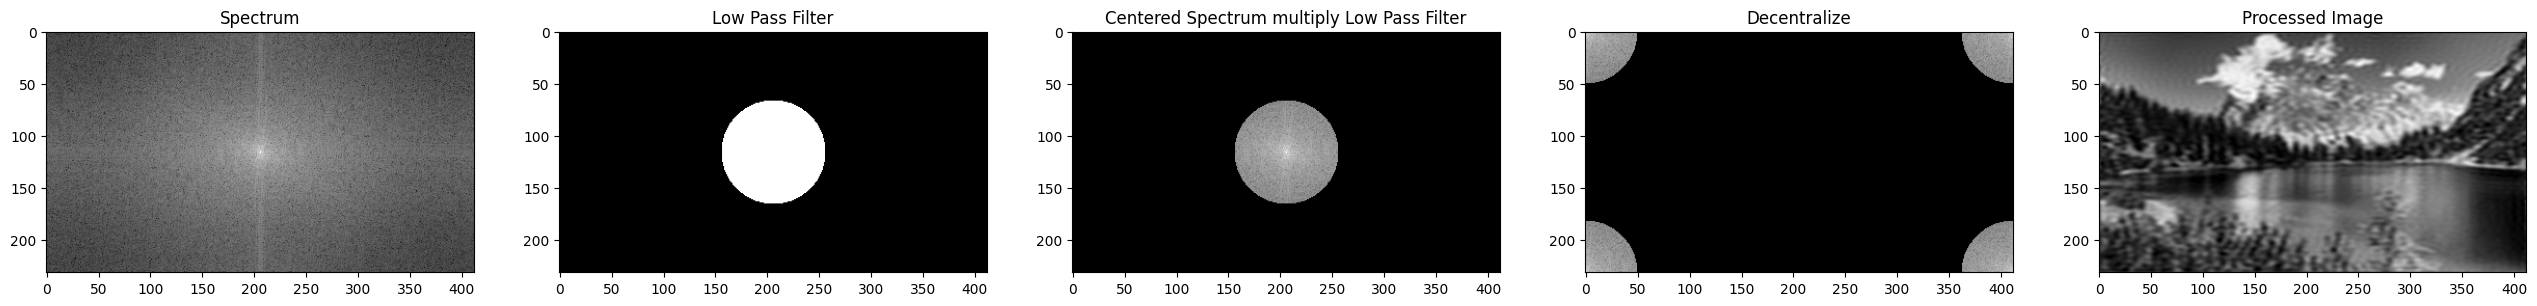

In [6]:
img = cv2.imread("image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(151), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Spectrum")

LowPass = idealFilterLP(50,img.shape)
plt.subplot(152), plt.imshow(np.abs(LowPass), "gray"), plt.title("Low Pass Filter")

LowPassCenter = center * idealFilterLP(50,img.shape)
plt.subplot(153), plt.imshow(np.log(1+np.abs(LowPassCenter)), "gray"), plt.title("Centered Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(154), plt.imshow(np.log(1+np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(155), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

## High Pass Filter <a class="anchor" id="high" ></a>

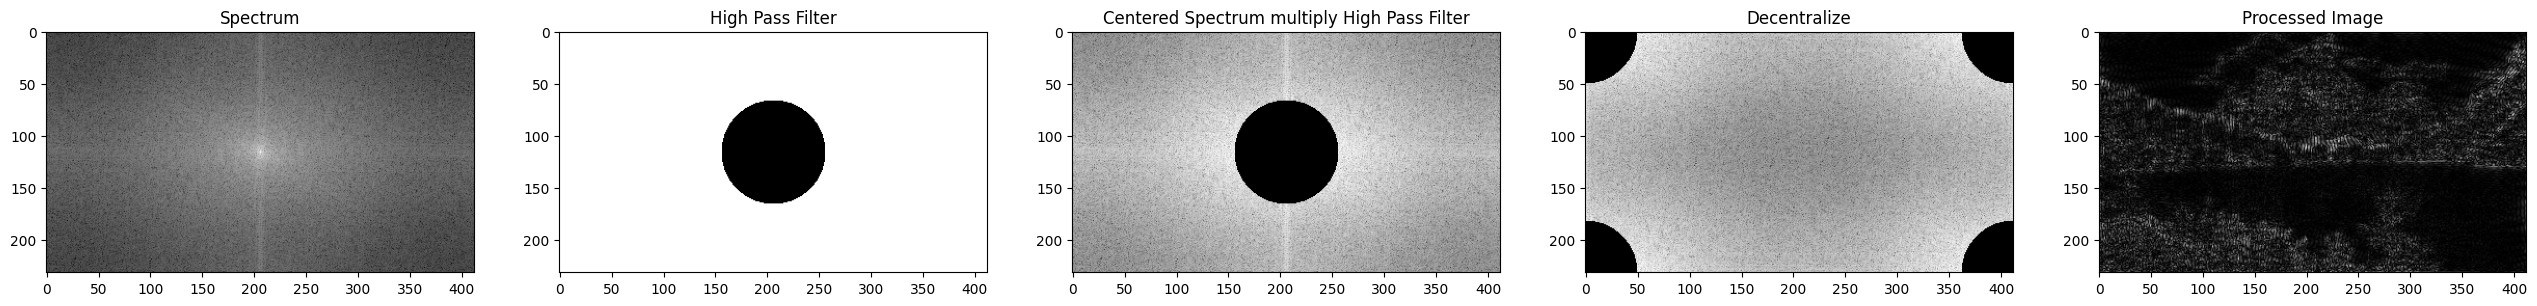

In [7]:
img = cv2.imread("image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(151), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Spectrum")

HighPass = idealFilterHP(50,img.shape)
plt.subplot(152), plt.imshow(np.abs(HighPass), "gray"), plt.title("High Pass Filter")

HighPassCenter = center * idealFilterHP(50,img.shape)
plt.subplot(153), plt.imshow(np.log(1+np.abs(HighPassCenter)), "gray"), plt.title("Centered Spectrum multiply High Pass Filter")

HighPass = np.fft.ifftshift(HighPassCenter)
plt.subplot(154), plt.imshow(np.log(1+np.abs(HighPass)), "gray"), plt.title("Decentralize")

inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(155), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Processed Image")

plt.show()

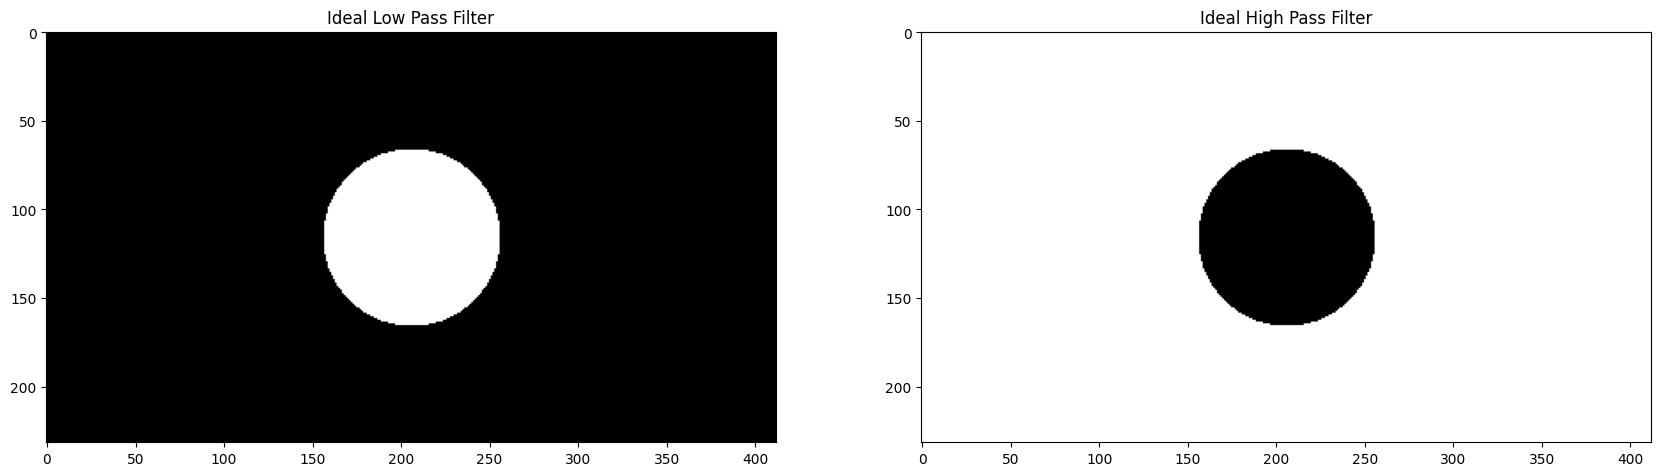

In [8]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = idealFilterLP(50,img.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Ideal Low Pass Filter")

HighPass = idealFilterHP(50,img.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Ideal High Pass Filter")

plt.show()

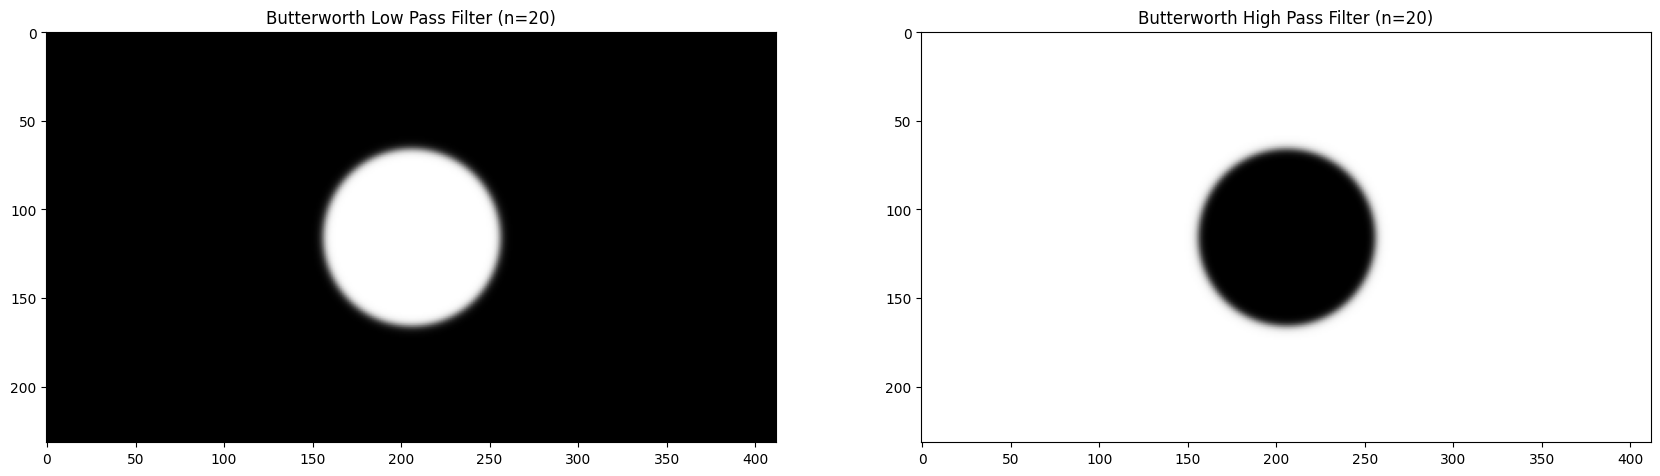

In [9]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = butterworthLP(50,img.shape,20)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Butterworth Low Pass Filter (n=20)")

HighPass = butterworthHP(50,img.shape,20)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Butterworth High Pass Filter (n=20)")

plt.show()

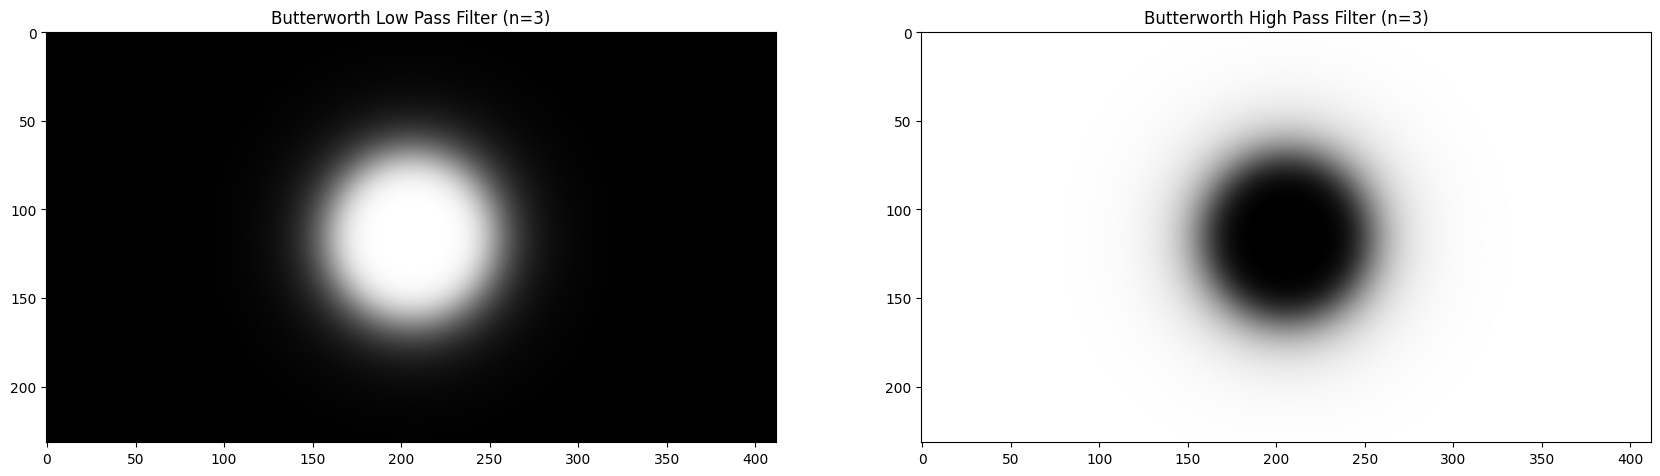

In [10]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = butterworthLP(50,img.shape,3)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Butterworth Low Pass Filter (n=3)")

HighPass = butterworthHP(50,img.shape,3)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Butterworth High Pass Filter (n=3)")

plt.show()

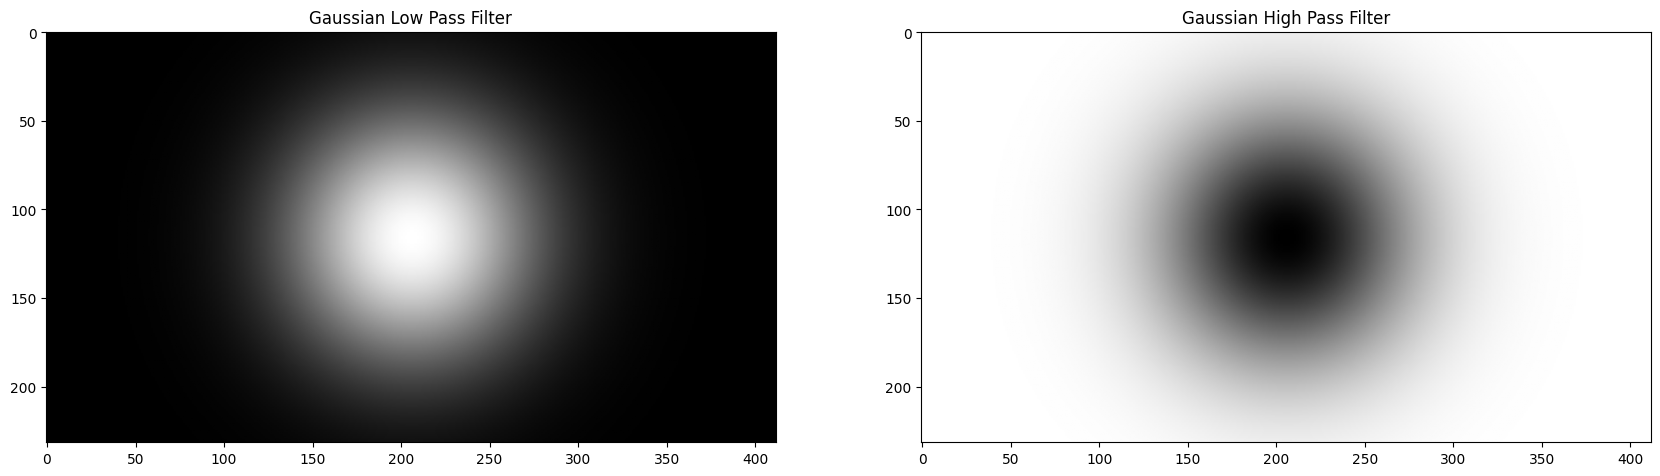

In [11]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = gaussianLP(50,img.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Gaussian Low Pass Filter")

HighPass = gaussianHP(50,img.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Gaussian High Pass Filter")

plt.show()

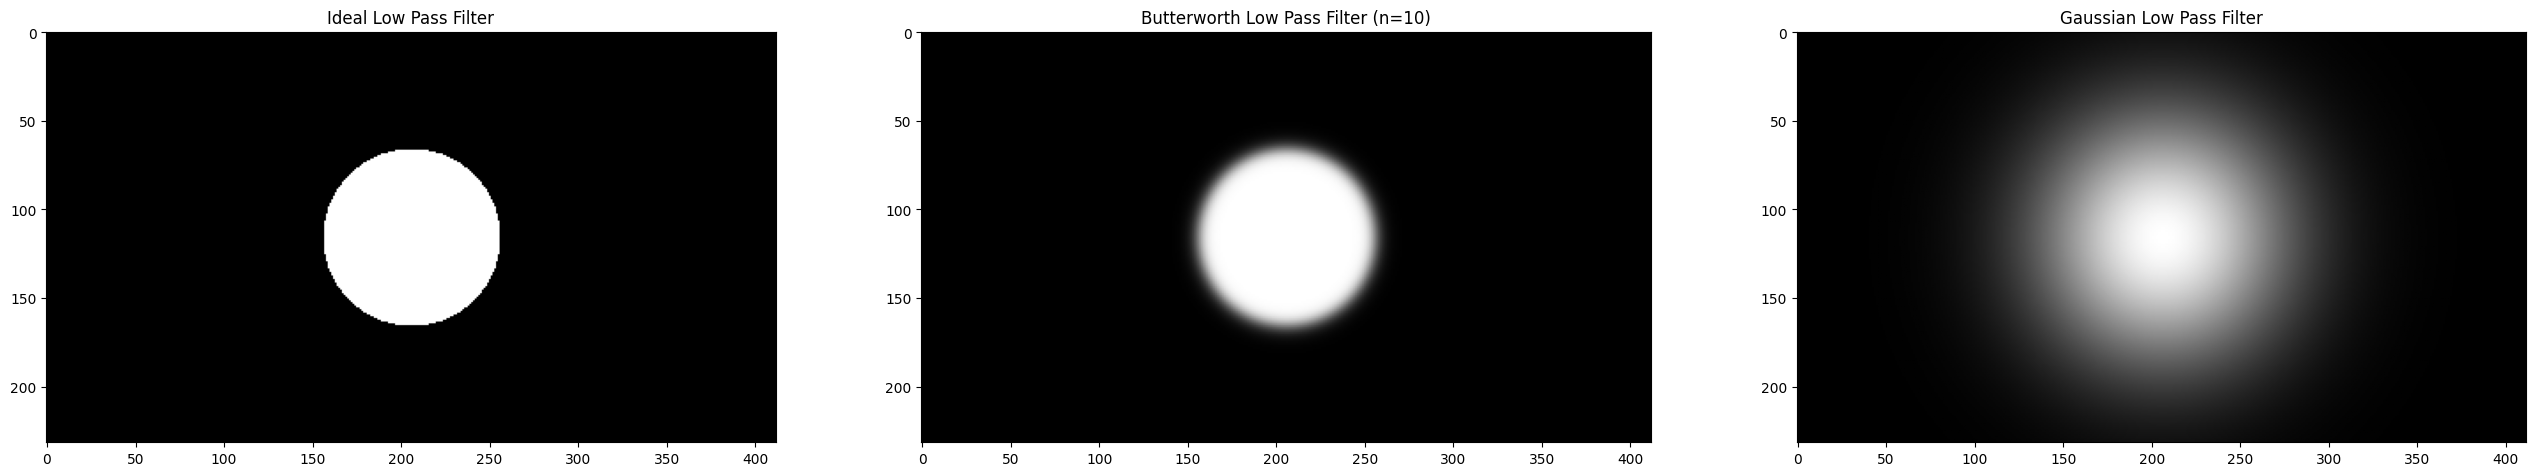

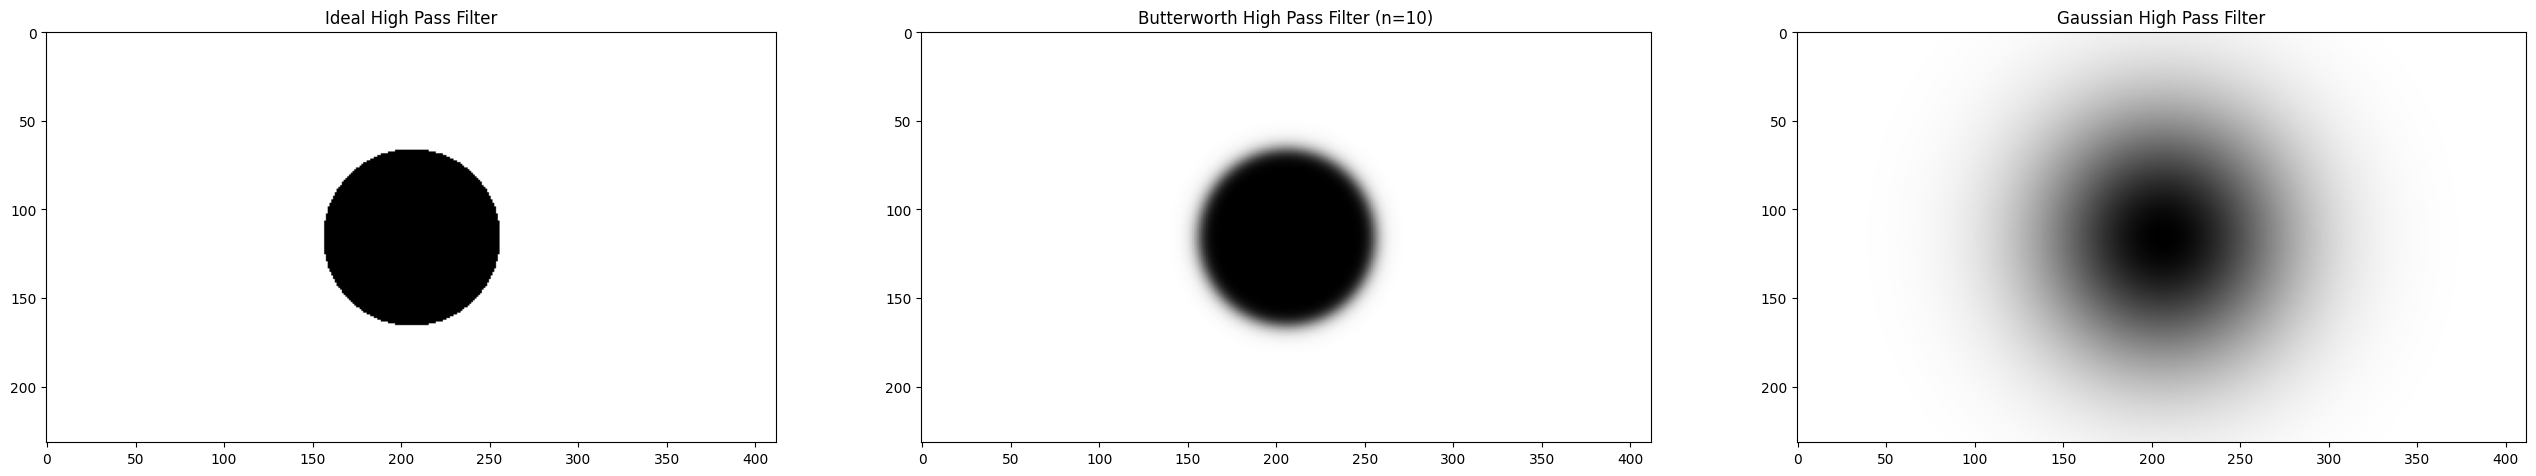

In [12]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

IdealLP = idealFilterLP(50,img.shape)
plt.subplot(131), plt.imshow(IdealLP, "gray"), plt.title("Ideal Low Pass Filter")

ButterLP = butterworthLP(50,img.shape,10)
plt.subplot(132), plt.imshow(ButterLP, "gray"), plt.title("Butterworth Low Pass Filter (n=10)")

GaussianLP = gaussianLP(50,img.shape)
plt.subplot(133), plt.imshow(GaussianLP, "gray"), plt.title("Gaussian Low Pass Filter")

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)
IdealHP = idealFilterHP(50,img.shape)
plt.subplot(231), plt.imshow(IdealHP, "gray"), plt.title("Ideal High Pass Filter")

ButterHP = butterworthHP(50,img.shape,10)
plt.subplot(232), plt.imshow(ButterHP, "gray"), plt.title("Butterworth High Pass Filter (n=10)")

GaussianHP = gaussianHP(50,img.shape)
plt.subplot(233), plt.imshow(GaussianHP, "gray"), plt.title("Gaussian High Pass Filter")

plt.show()

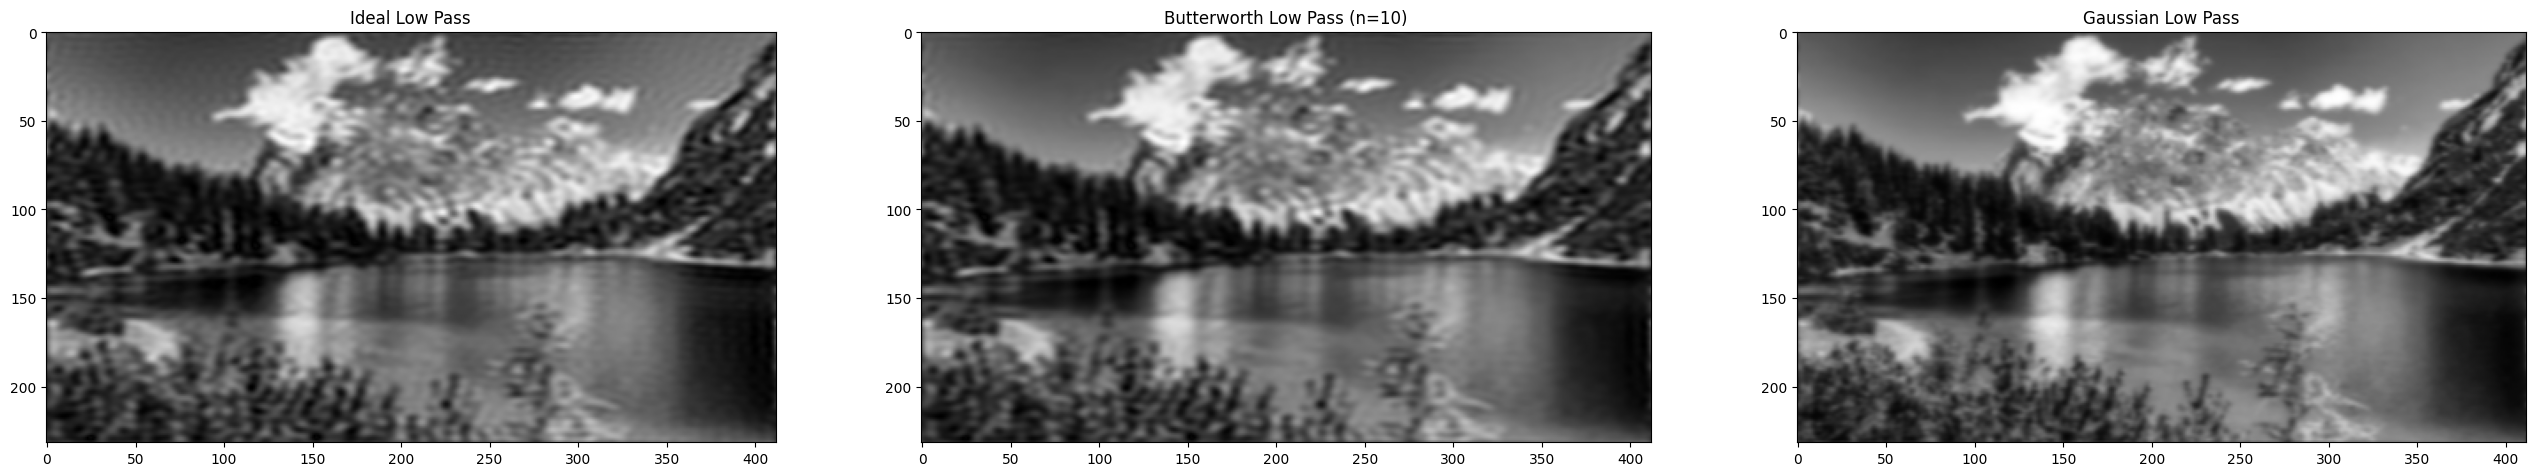

In [13]:
img = cv2.imread("image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPassCenter = center * idealFilterLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(131), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Ideal Low Pass")

LowPassCenter = center * butterworthLP(50,img.shape,10)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(132), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (n=10)")

LowPassCenter = center * gaussianLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(133), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Gaussian Low Pass")

plt.show()

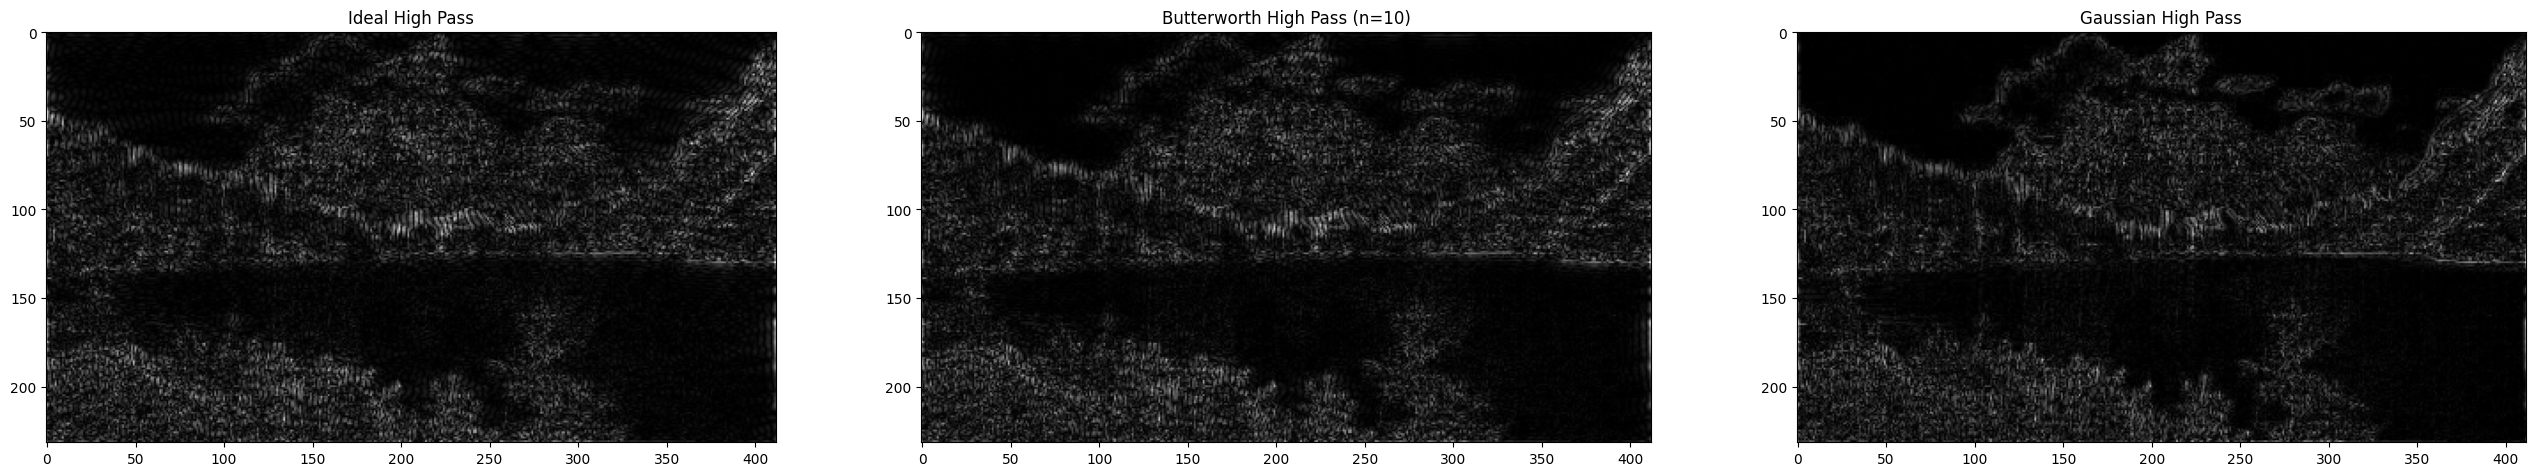

In [14]:
img = cv2.imread("image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

HighPassCenter = center * idealFilterHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(131), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Ideal High Pass")

HighPassCenter = center * butterworthHP(50,img.shape,10)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(132), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (n=10)")

HighPassCenter = center * gaussianHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(133), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

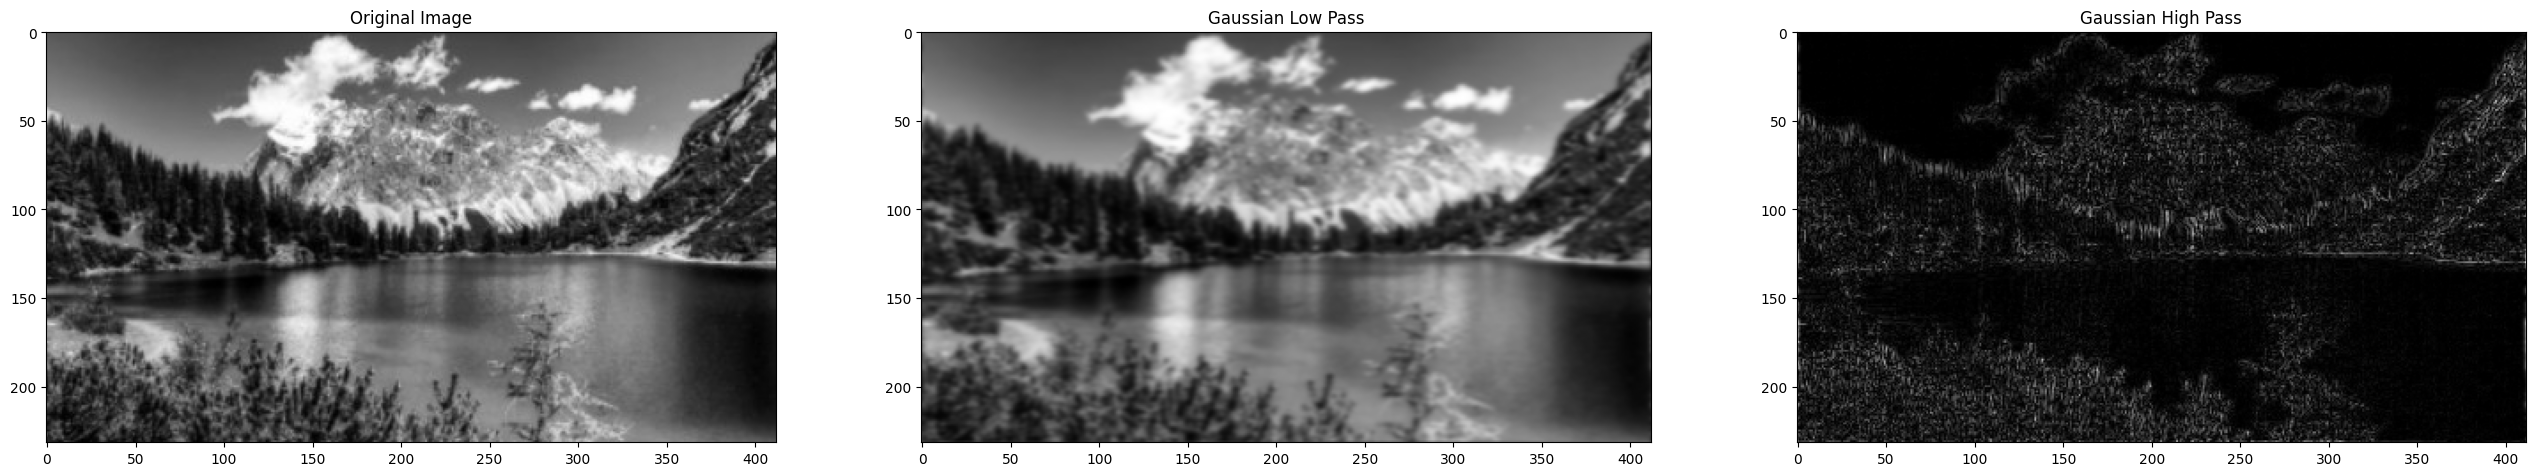

In [15]:
img = cv2.imread("image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(131), plt.imshow(img, "gray"), plt.title("Original Image")

LowPassCenter = center * gaussianLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(132), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Gaussian Low Pass")

HighPassCenter = center * gaussianHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(133), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

## Ejercicios <a class="anchor" id="ejer" ></a>

Aplicación de mejoramiento de imágenes usando transformada de Fourier usando filtro pasabajas

**1.Reducción de ruido en imágenes:** La eliminación de ruido en imágenes médicas, como las resonancias magnéticas y las tomografías, es crucial para obtener resultados más precisos en diagnósticos.

In [16]:
def ideal_lowpass_filter(shape, cutoff):
    rows, cols = shape
    mask = np.zeros((rows, cols), np.uint8)
    center = (rows//2, cols//2)
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i - center[0])**2 + (j - center[1])**2) <= cutoff:
                mask[i, j] = 1
    return mask

def butterworth_lowpass_filter(shape, cutoff, order=2):
    rows, cols = shape
    mask = np.zeros((rows, cols), np.float32)
    center = (rows//2, cols//2)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center[0])**2 + (j - center[1])**2)
            mask[i, j] = 1 / (1 + (distance / cutoff) ** (2 * order))
    return mask

def gaussian_lowpass_filter(shape, cutoff):
    rows, cols = shape
    mask = np.zeros((rows, cols), np.float32)
    center = (rows//2, cols//2)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center[0])**2 + (j - center[1])**2)
            mask[i, j] = np.exp(- (distance**2) / (2 * (cutoff**2)))
    return mask



def ideal_highpass_filter(shape, cutoff):
    rows, cols = shape
    mask = np.ones((rows, cols), np.uint8)
    center = (rows // 2, cols // 2)
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i - center[0])**2 + (j - center[1])**2) <= cutoff:
                mask[i, j] = 0
    return mask

def butterworth_highpass_filter(shape, cutoff, order=2):
    rows, cols = shape
    mask = np.ones((rows, cols), np.float32)
    center = (rows // 2, cols // 2)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center[0])**2 + (j - center[1])**2)
            mask[i, j] = 1 - (1 / (1 + (distance / cutoff) ** (2 * order)))
    return mask

def gaussian_highpass_filter(shape, cutoff):
    rows, cols = shape
    mask = np.ones((rows, cols), np.float32)
    center = (rows // 2, cols // 2)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - center[0])**2 + (j - center[1])**2)
            mask[i, j] = 1 - np.exp(- (distance**2) / (2 * (cutoff**2)))
    return mask

def apply_filter(img, filter_func, cutoff, order=2):

    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    if filter_func in [butterworth_lowpass_filter, butterworth_highpass_filter]:
        mask = filter_func(img.shape, cutoff, order)
    else:
        mask = filter_func(img.shape, cutoff)

    dft_filtered = dft_shift * mask
    dft_ishift = np.fft.ifftshift(dft_filtered)
    img_filtered = np.fft.ifft2(dft_ishift)
    return np.abs(img_filtered), mask



### a) Investigar una aplicación de mejoramiento de imágenes usando transformada de Fourier usando filtro pasabajas.

## Eliminación de ruido en imágenes de resonancia magnética (MRI)

Las imágenes de resonancia magnética (RM) son sensibles a diversas fuentes de ruido, que pueden comprometer la calidad de la imagen y dificultar el diagnóstico clínico. Uno de los tipos más comunes de ruido en estas imágenes es el ruido de alta frecuencia, que se origina principalmente por fluctuaciones aleatorias en los datos de adquisición, variaciones en los campos magnéticos, e imperfecciones en el hardware del sistema de resonancia magnética. Este ruido de alta frecuencia puede manifestarse como interferencias pixeladas o granuladas en las imágenes, lo que puede hacer que los detalles más finos de las estructuras internas sean difíciles de discernir.

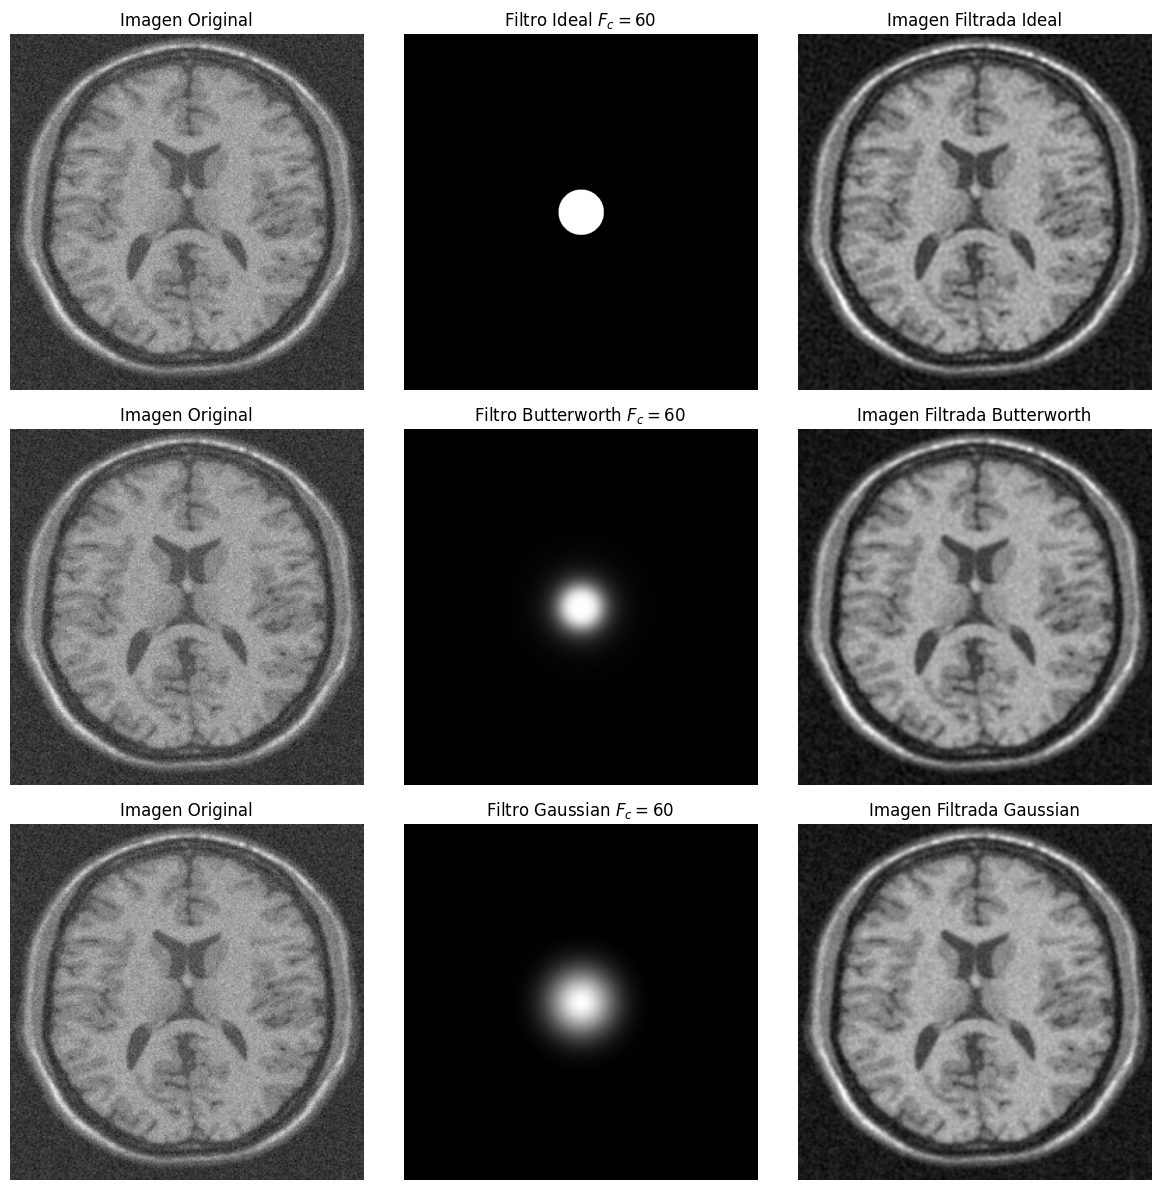

In [17]:
img = Image.open("MRI_noisy.tif")
img = np.array(img)

cutoff = 60
ideal_filtered, ideal_mask = apply_filter(img, ideal_lowpass_filter, cutoff)
butter_filtered, butter_mask = apply_filter(img, butterworth_lowpass_filter, cutoff, order=2)
gaussian_filtered, gaussian_mask = apply_filter(img, gaussian_lowpass_filter, cutoff)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
filters = [(ideal_filtered, ideal_mask, "Ideal"), (butter_filtered, butter_mask, "Butterworth"), (gaussian_filtered, gaussian_mask, "Gaussian")]

for i, (filtered, mask, title) in enumerate(filters):
    for j, img_to_show in enumerate([img, mask, filtered]):
        axes[i, j].imshow(img_to_show, cmap='gray')
        axes[i, j].set_title(f"{'Imagen Original' if j == 0 else f'Filtro {title} $F_c = {cutoff}$ ' if j == 1 else f'Imagen Filtrada {title}'}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

### b) Investigar una aplicación de mejoramiento de imágenes usando transformada de Fourier usando filtro pasa altas.

## Detección de fracturas óseas en radiografías

En imágenes de rayos X, las fracturas pueden ser difíciles de detectar debido a variaciones en el contraste y la presencia de tejidos blandos. Un filtro pasa altas puede resaltar los bordes de los huesos y mejorar la visibilidad de fracturas y fisuras.

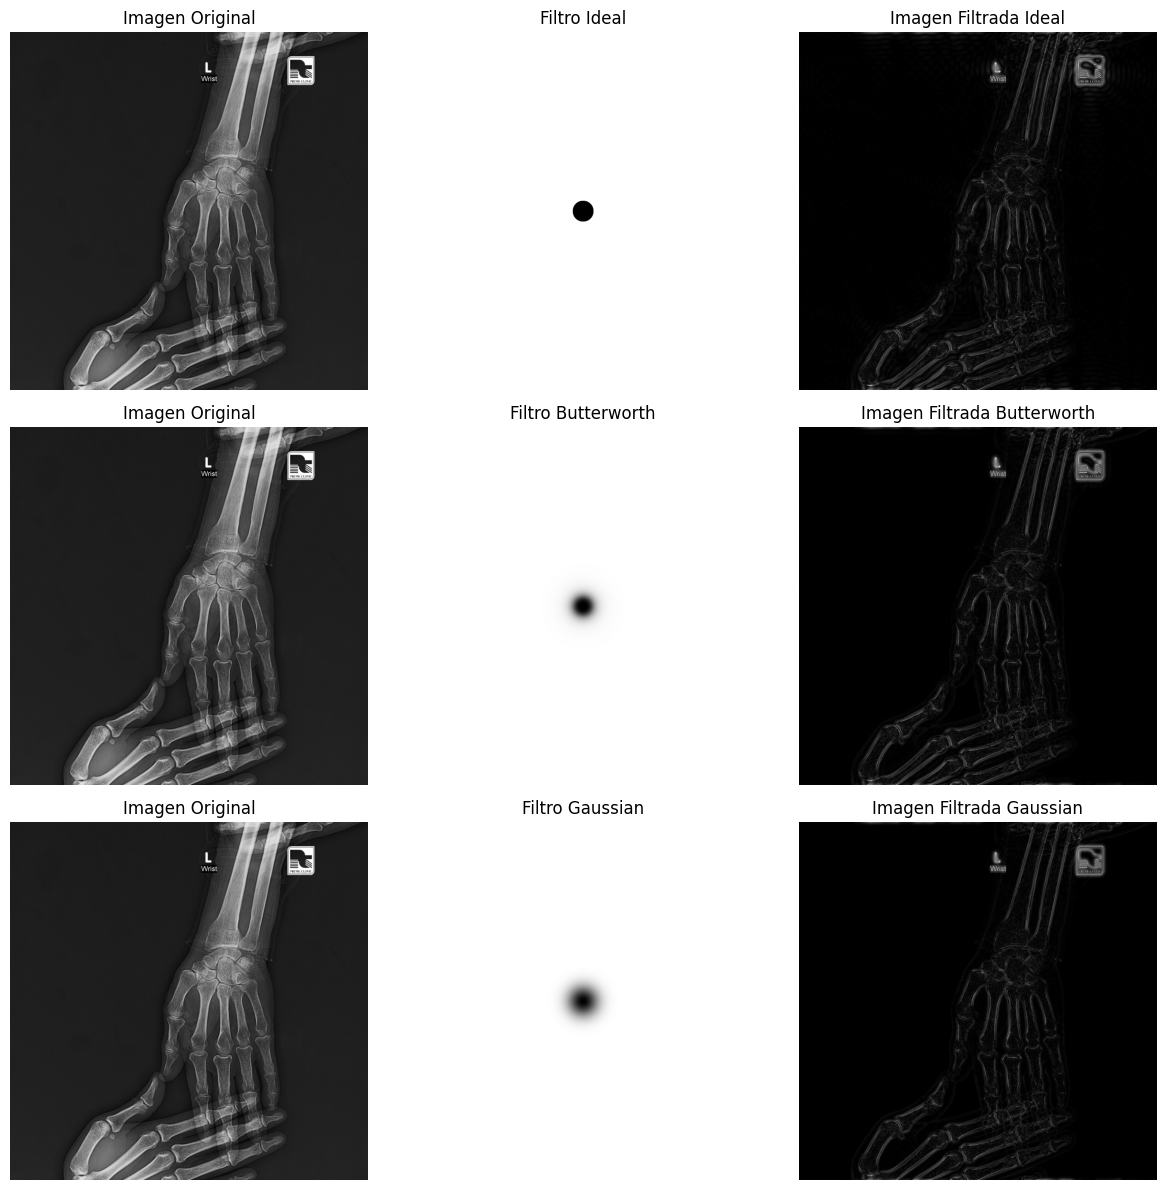

In [18]:
# Cargar imagen en escala de grises
img = cv2.imread("dataset-card.jpg", 0)

# Definir la frecuencia de corte
cutoff = 35

# Aplicar filtros pasa-altas
ideal_filtered, ideal_mask = apply_filter(img, ideal_highpass_filter, cutoff)
butter_filtered, butter_mask = apply_filter(img, butterworth_highpass_filter, cutoff, order=2)
gaussian_filtered, gaussian_mask = apply_filter(img, gaussian_highpass_filter, cutoff)

# Mostrar resultados
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
filters = [(ideal_filtered, ideal_mask, "Ideal"), (butter_filtered, butter_mask, "Butterworth"), (gaussian_filtered, gaussian_mask, "Gaussian")]

for i, (filtered, mask, title) in enumerate(filters):
    for j, img_to_show in enumerate([img, mask, filtered]):
        axes[i, j].imshow(img_to_show, cmap='gray')
        axes[i, j].set_title(f"{'Imagen Original' if j == 0 else f'Filtro {title}' if j == 1 else f'Imagen Filtrada {title}'}")
        axes[i, j].axis("off")  # Quitar ejes

plt.tight_layout()
plt.show()


## Referencias <a class="anchor" id="ref" ></a>


* Gonzalez, R. & Woods, R. (2018). Digital Image Processing.  4° Edition. Pearson.
* OpenCV. (n.d.). Fourier Transform (tutorial). Retrieved from https://docs.opencv.org/3.4/de/dbc/tutorial_py_fourier_transform.html
* Rosebrock, A. (2020, June 15). OpenCV Fast Fourier Transform (FFT) for blur detection in images and video streams. PyImageSearch. Retrieved from https://pyimagesearch.com/2020/06/15/opencv-fast-fourier-transform-fft-for-blur-detection-in-images-and-video-streams/
* Dayal, D. (2019, November 12). Frequency domain filtering on an image using OpenCV. Medium. Retrieved from https://medium.com/@devangdayal/frequency-domain-filtering-on-an-image-using-opencv-26bfcc97e23b
* Weiskopf, N., Lutti, A., & Turner, R. (2014). The influence of filter size on the quality of magnetic resonance imaging. Magnetic Resonance in Medicine, 71(5), 1603–1612. https://doi.org/10.1002/mrm.24714
* Doi, K., MacMahon, H., & Hara, T. (2009). Computer-aided diagnosis in medical imaging: Intelligent imaging systems for clinical decision support. CRC Press.



In [21]:
! jupyter nbconvert --to html /content/Frequency_Domain_Eq23.ipynb


[NbConvertApp] Converting notebook /content/Frequency_Domain_Eq23.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 9302553 bytes to /content/Frequency_Domain_Eq23.html
